In [1]:
%%script false --no-raise-error
!pip3 install opencv-python numpy matplotlib opendatasets pandas kagglehub ace_tools

In [2]:
%%script false --no-raise-error
!kaggle datasets download -d adamelkholy/human-ai-artwork
!mkdir data
!unzip human-ai-artwork.zip -d data
!rm *.zip

In [3]:
## Package Imports

In [4]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # Hide INFO & WARNING logs

import tensorflow as tf
tf.get_logger().setLevel("ERROR")  # Only show errors

import time
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np 

Future exception was never retrieved
future: <Future finished exception=BrokenPipeError(32, 'Broken pipe')>
Traceback (most recent call last):
  File "/usr/lib/python3.10/asyncio/unix_events.py", line 676, in write
    n = os.write(self._fileno, data)
BrokenPipeError: [Errno 32] Broken pipe


## Pre-Processing

In [5]:
### Splits and Tuning

In [6]:
weights = {0: 1.0, 1: 1.0} 
num_classes = 1
batch_size = 32
img_ht = 256
img_wt = 256
data_dir = "./data/data"
model_path = "./"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.4,
    subset="training",
    seed=104,
    image_size=(img_ht, img_wt),
    batch_size = batch_size
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.4,
    subset="validation",
    seed=104,
    image_size=(img_ht, img_wt),
    batch_size=batch_size
)

val_batches = int(0.5 * len(val_test_ds))
val_ds = val_test_ds.take(val_batches)
test_ds = val_test_ds.skip(val_batches)

Found 271993 files belonging to 52 classes.
Using 163196 files for training.


I0000 00:00:1739278060.042320  365362 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1739278060.042573  365362 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1739278060.070112  365362 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1739278060.070317  365362 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Found 271993 files belonging to 52 classes.
Using 108797 files for validation.


### Imbalance Bias

In [7]:
pos = 190549
neg = 81457
in_bias = np.log([pos/neg])
out_bias = tf.keras.initializers.Constant(in_bias)

### Image to Binary Mappings

In [8]:
def image_to_binary(img, label):
    label = tf.cast(label, tf.int32)
    new_label = tf.where(label < 25, 1, 0) # label is number of ai class folders
    new_label = tf.expand_dims(new_label, axis=-1)
    return (img, new_label)


train_ds = train_ds.map(image_to_binary)
val_ds = val_ds.map(image_to_binary)
test_ds = test_ds.map(image_to_binary)

In [9]:
## Data Augmentation

In [10]:
def img_augmentation(img, lbl):
    min_scale = 0.5
    max_scale = 2.0
    scale_factor = tf.random.uniform(shape=[], minval=min_scale, maxval=max_scale)
    resized_img = tf.image.resize(img, tf.cast(tf.cast(tf.shape(img)[1:3], tf.float32) * scale_factor, tf.int32))
    rescaled_img = tf.image.resize(resized_img, tf.shape(img)[1:3])
    
    return (rescaled_img, lbl)

train_ds = train_ds.map(img_augmentation)
val_ds = val_ds.map(img_augmentation)
test_ds = test_ds.map(img_augmentation)

## Model Training

### Define Models for Experimenting

In [17]:
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet50, NASNetMobile, DenseNet121, Xception, VGG16
from tensorflow.keras import layers, models

# Function to Create a Binary Classification Model
def create_binary_model(base_model, model_name):
    base_model.trainable = False  # Freeze pre-trained layers
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dense(1, activation="sigmoid")(x)  # Binary classification output
    model = models.Model(inputs=base_model.input, outputs=x, name=model_name)
    return model

# Load Models with `include_top=False` to Customize Output
resnet_base = ResNet50(weights="imagenet", include_top=False, input_shape=(256, 256, 3))
resnet_model = create_binary_model(resnet_base, "ResNet50")

densenet_base = DenseNet121(weights="imagenet", include_top=False, input_shape=(256, 256, 3))
densenet_model = create_binary_model(densenet_base, "DenseNet121")

xception_base = Xception(weights="imagenet", include_top=False, input_shape=(256, 256, 3))
xception_model = create_binary_model(xception_base, "Xception")

vgg16_base = VGG16(weights="imagenet", include_top=False, input_shape=(256, 256, 3))
vgg16_model = create_binary_model(vgg16_base, "VGG16")

mobilenet_base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(256, 256, 3))
mobilenet_model = create_binary_model(mobilenet_base, "MobileNetV2")

nasnet_base = NASNetMobile(weights="imagenet", include_top=False, input_shape=(256, 256, 3))
nasnet_model = create_binary_model(nasnet_base, "NASNetMobile")

# Vision Transformer (ViT) - Custom Model with Correct Output
def build_vit_model():
    inputs = layers.Input(shape=(256, 256, 3))
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)  # Fixed for binary classification
    model = models.Model(inputs, outputs, name="VisionTransformer")
    return model

vit_model = build_vit_model()

# Custom CNN (DejAIvu Model) - Already Supports Binary Classification
dejaivu_model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation="sigmoid")  # Binary classification
])

dejaivu_model.name = "dejAIvu_model"

# Store models in dictionary
models_dict = {
    "ResNet50": resnet_model,
    "DenseNet121": densenet_model,
    "Xception": xception_model,
    "VGG16": vgg16_model,
    "MobileNetV2": mobilenet_model,
    "NASNetMobile": nasnet_model,
    "VisionTransformer": vit_model,
    "dejAIvu_model": dejaivu_model
}

best_model = resnet_model
best_accuracy = 0.9714
best_model_name = "ResNet50"

results = {}

/tmp/ipykernel_365362/24934264.py:25: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(256, 256, 3))


### Metrics

In [12]:
metrics = [
      tf.keras.metrics.BinaryAccuracy(name='accuracy'),
      tf.keras.metrics.BinaryCrossentropy(name='cross entropy'), # equiv. to model's loss
      tf.keras.metrics.MeanSquaredError(name='MSE'),
      tf.keras.metrics.TruePositives(name='tp'),
      tf.keras.metrics.FalsePositives(name='fp'),
      tf.keras.metrics.TrueNegatives(name='tn'),
      tf.keras.metrics.FalseNegatives(name='fn'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name='recall'),
      tf.keras.metrics.AUC(name='roc', curve='ROC'),             # receiver operating characteristic curve
      tf.keras.metrics.AUC(name='prc', curve='PR'),              # precision-recall curve
]

class CustomHistory(tf.keras.callbacks.Callback):
    def __init__(self):
      super(CustomHistory, self).__init__()
      self.losses = []
      self.prcs = []
      self.recalls = []
      self.precisions = []
      self.accuracies = []
      self.mses = []

    """ called upon completion of each batch during training, records all performance metrics """
    def on_train_batch_end(self, batch, logs=None):
      self.losses.append(logs['loss'])
      self.mses.append(logs['MSE'])
      self.accuracies.append(logs['accuracy'])
      self.prcs.append(logs['prc'])
      self.recalls.append(logs['recall'])
      self.precisions.append(logs['precision'])

    """ called upon completion of each batch during testing, records all performance metrics """
    def on_test_batch_end(self, batch, logs=None):
      self.losses.append(logs['loss'])
      self.mses.append(logs['MSE'])
      self.accuracies.append(logs['accuracy'])
      self.prcs.append(logs['prc'])
      self.recalls.append(logs['recall'])
      self.precisions.append(logs['precision'])

    """ return all performance metrics """
    def get_metrics(self):
      return self.losses, self.mses, self.accuracies, self.prcs, self.recalls, self.precisions

## Model Training

### Compiling and Evaluating Helpers

In [13]:
def compile_model(model):
  model.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=metrics
  )
  return model

def fit_model(model):
  history_callback = CustomHistory()
  model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    class_weight=weights,
    callbacks=[history_callback]
  )
  return model, history_callback

def evaluate_model_on_test(model):
  eval_metrics = model.evaluate(test_ds)
  return eval_metrics

def save_model(model):
  model_name = model.name
  print("\nSaving " + model_name + ".keras")
  try:
    model.save(model_path + model_name + ".keras")
  except:
    print("Error saving " + model_name + ".keras...")
    return
  print(model_name + ".keras saved successfully.\n")
  
def save_data(data, filename):
  print("Saving data for " + filename)
  try:
    with open(model_path + filename+".txt", 'w') as writefile:
      writefile.write(str(data))
  except:
    print("Error saving data for " + filename)
    return
  print("Data saved.\n")
  
def load_evals(filename):
    file_path = f"{filename}.txt"
    
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Evaluation file {file_path} not found.")

    with open(file_path, "r") as file:
        evals = eval(file.readline().strip())  # Read and convert string list to actual list

    if not isinstance(evals, list):
        raise ValueError(f"Invalid format in {file_path}. Expected a list of numbers.")

    return {
        "loss": evals[0],
        "accuracy": evals[1],
        "val_loss": evals[2],
        "val_accuracy": evals[3],
        "true_positives": evals[4],
        "false_positives": evals[5],
        "true_negatives": evals[6],
        "false_negatives": evals[7],
        "precision": evals[8],
        "recall": evals[9],
        "f1_score": evals[10],
        "auc": evals[11],
    }

# Load training history from history.txt (formatted as a list of lists)
def load_history(filename):
    file_path = f"{filename}.txt"
    
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"History file {file_path} not found.")

    with open(file_path, "r") as file:
        history = eval(file.readline().strip())  # Read and convert string list to actual list

    if not isinstance(history, list) or len(history) < 6:
        raise ValueError(f"Invalid format in {file_path}. Expected a list of metric lists.")

    return {
        "losses": history[0],
        "mses": history[1],  # Mean Squared Errors
        "accuracies": history[2],
        "prcs": history[3],  # Precision over time
        "recalls": history[4],
        "precisions": history[5],
    }

### Execute Training


In [14]:
from tensorflow.keras.metrics import MeanSquaredError, AUC, Recall, Precision

def train_model_pipeline(model, mname, lr=0.001):
  start = time.time()
  model_name = model.name
  print("Now training " + model_name)

  # compile model and fit to training data
  compiled_model = compile_model(model)
  compiled_model.optimizer.learning_rate = lr
  trained_model, history = fit_model(compiled_model)

  # save model.keras and history data
  save_data(history.get_metrics(), model_name+"_history")
  save_model(trained_model)

  # evaluate on test set and save evaluation
  evals = evaluate_model_on_test(trained_model)
  save_data(evals, model_name + "_evals")

  time_taken = time.time() - start
  
  final_accuracy = evals[1]
  
  print(f"Training complete for {model_name} in", round((time_taken)/60, 2), "minutes")
  return trained_model, evals, history, final_accuracy


In [ ]:
for model_name, model in models_dict.items():
    print(f"Training {model_name}...")
    trained_model, evals, history, final_accuracy = train_model_pipeline(model, model_name)
    results[model_name] = {"evals": evals, "history": history.get_metrics(), "accuracy": final_accuracy}
    
    if final_accuracy > best_accuracy:
        best_accuracy = final_accuracy
        best_model = trained_model
        best_model_name = model_name

if best_model is not None:
    print(f"Best model is {best_model_name} with accuracy: {best_accuracy:.4f}")
    best_model.save(f"best_model_{best_model_name}.keras")

## Display Metrics

### Tables

In [35]:
model_file_sizes = {
    "ResNet50": 90.63,
    "DenseNet121": 28.30,
    "Xception": 80.08,
    "VGG16": 56.22,
    "MobileNetV2": 9.18,
    "NASNetMobile": 18.91,
    "VisionTransformer": 1.67,
    "dejAIvu_model": 163.77,
}

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display  # Alternative 1

# Prepare results for table
data = []
for model_name, _ in models_dict.items():
    evals = load_evals(f"{model_name}_evals")

    last_epoch_metrics = {
        "Model": model_name,
        "Accuracy": evals["accuracy"],
        "Loss": evals["loss"],
        "Precision": evals["precision"],
        "Recall": evals["recall"],
        "File Size (MB)": model_file_sizes.get(model_name, "N/A")  # Add file size
    }
    data.append(last_epoch_metrics)

# Convert to DataFrame
df = pd.DataFrame(data)

# Highlight best model


# Sort models by accuracy
df_sorted = df.sort_values(by="Accuracy", ascending=False)

In [56]:
import pandas as pd

# Convert numeric columns to float and format them nicely
df_sorted["Accuracy"] = df_sorted["Accuracy"].astype(float).apply(lambda x: f"{x:.3f}")
df_sorted["Loss"] = df_sorted["Loss"].astype(float).apply(lambda x: f"{x:.3f}")
df_sorted["Precision"] = df_sorted["Precision"].astype(float).apply(lambda x: f"{x:.3f}")
df_sorted["Recall"] = df_sorted["Recall"].astype(float).apply(lambda x: f"{x:.3f}")

# Ensure File Size (MB) is formatted properly
df_sorted["File Size (MB)"] = df_sorted["File Size (MB)"].apply(lambda x: f"{float(x):.1f}" if isinstance(x, (int, float)) else x)

# Set "Model" column as index to avoid showing row numbers
df_sorted = df_sorted.set_index("Model")

# Apply Pandas Styler for better appearance
styled_df = df_sorted.style.set_properties(**{
    'background-color': '#f4f4f4',  
    'border': '1px solid black',
    'color': 'black',
    'text-align': 'center'
}).set_table_styles([
    {"selector": "thead th", "props": [("font-weight", "bold"), ("background-color", "#ddd")]}
])

# Display the formatted table in Jupyter Notebook
display(styled_df)


,Accuracy,Loss,Precision,Recall,File Size (MB)
Model,,,,,
ResNet50,0.971,0.081,0.981,0.978,90.6
VisionTransformer,0.960,0.113,0.968,0.974,1.7
dejAIvu_model,0.950,0.145,0.970,0.958,163.8
VGG16,0.929,0.190,0.941,0.958,56.2
DenseNet121,0.919,0.214,0.928,0.959,28.3
MobileNetV2,0.882,0.284,0.897,0.939,9.2
Xception,0.782,0.586,0.921,0.754,80.1
NASNetMobile,0.767,0.496,0.826,0.846,18.9


### Graphs Per Model

<Figure size 1200x600 with 0 Axes>

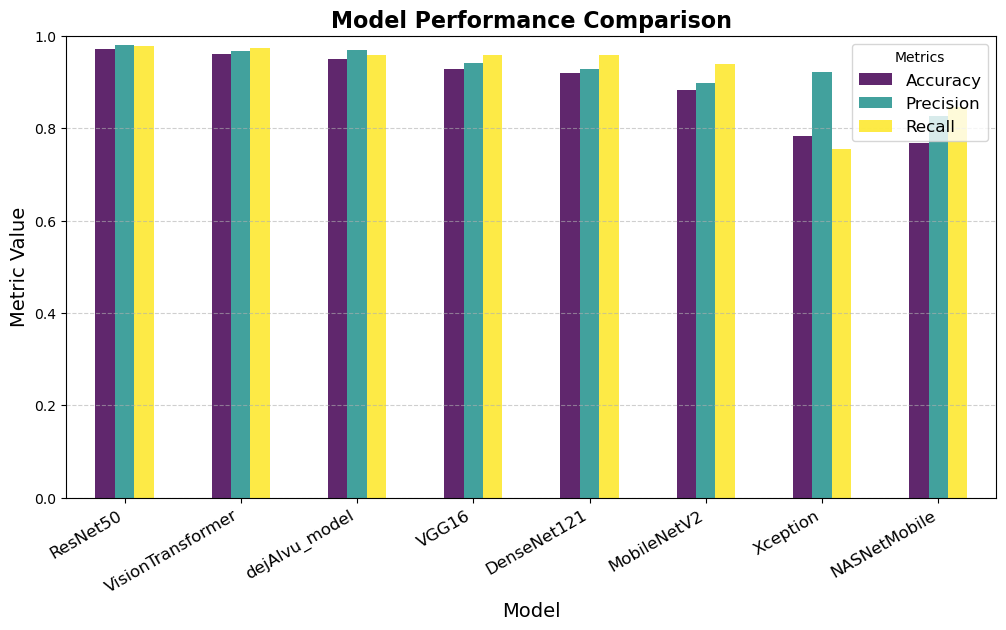

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert values back to float for plotting
df_sorted_numeric = df_sorted.copy()
for col in ["Accuracy", "Loss", "Precision", "Recall", "File Size (MB)"]:
    df_sorted_numeric[col] = df_sorted_numeric[col].astype(float)

plt.figure(figsize=(12, 6))
df_sorted_numeric[["Accuracy", "Precision", "Recall"]].plot(kind='bar', figsize=(12, 6), colormap="viridis", alpha=0.85)

plt.title("Model Performance Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Model", fontsize=14)
plt.ylabel("Metric Value", fontsize=14)
plt.xticks(rotation=30, ha="right", fontsize=12)
plt.ylim(0, 1)  # Keep y-axis in range [0,1]
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(fontsize=12, title="Metrics")

plt.show()


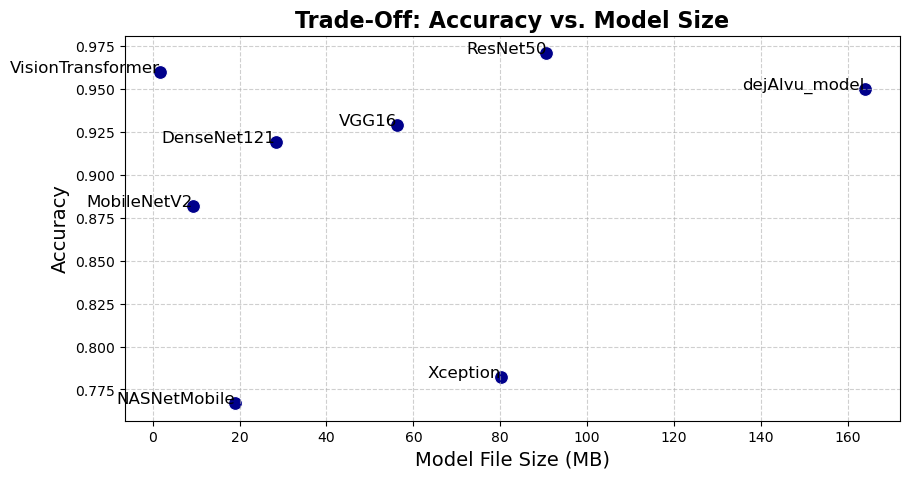

In [59]:
plt.figure(figsize=(10, 5))

sns.scatterplot(x="File Size (MB)", y="Accuracy", data=df_sorted_numeric, s=100, color="darkblue")

plt.title("Trade-Off: Accuracy vs. Model Size", fontsize=16, fontweight="bold")
plt.xlabel("Model File Size (MB)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)

# Annotate each point with the model name
for i, row in df_sorted_numeric.iterrows():
    plt.text(row["File Size (MB)"], row["Accuracy"], i, fontsize=12, ha="right", color="black")

plt.show()


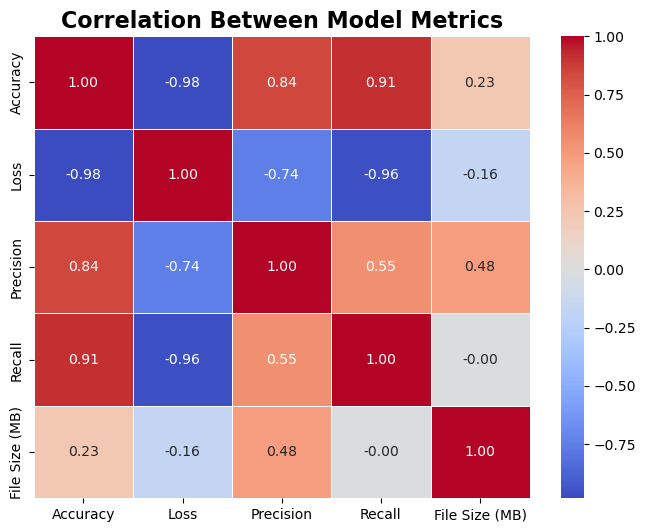

In [60]:
import numpy as np

plt.figure(figsize=(8, 6))
correlation_matrix = df_sorted_numeric.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")

plt.title("Correlation Between Model Metrics", fontsize=16, fontweight="bold")

plt.show()
